# Tumor Detection Using Yolov11

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import os
os.chdir('/content/drive/MyDrive/Colab/Yolo/Brain Tomor Detection /Tumor data')

In [6]:
import cv2
import matplotlib.pyplot as plt

In [7]:
#!pip install ultralytics
from ultralytics import YOLO
model = YOLO('/content/drive/MyDrive/Colab/Yolo/Brain Tomor Detection /Tumor data/yolo11m.pt')

In [11]:
import torch
print("CUDA available:", torch.cuda.is_available())

CUDA available: False


In [ ]:
model.train(
    data='/content/drive/MyDrive/Colab/Yolo/Brain Tomor Detection /Tumor data/data.yaml',
    epochs=70,
    #resume=True,
    device='cpu'
)



Ultralytics 8.3.199 🚀 Python-3.12.11 torch-2.8.0+cu126 CPU (AMD EPYC 7B12)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Colab/Yolo/Brain Tomor Detection /Tumor data/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=70, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/Colab/Yolo/Brain Tomor Detection /Tumor data/yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train6, nbs=64, nms=False, ops

In [ ]:
metrics = model.val()
print(metrics)


In [8]:
model.export(format='onnx')

Ultralytics 8.3.199 🚀 Python-3.12.11 torch-2.8.0+cu126 CPU (AMD EPYC 7B12)
YOLO11m summary (fused): 125 layers, 20,091,712 parameters, 0 gradients, 68.0 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/Colab/Yolo/Brain Tomor Detection /Tumor data/yolo11m.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (38.8 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0', 'onnxslim>=0.1.67', 'onnxruntime'] not found, attempting AutoUpdate...

requirements: AutoUpdate success ✅ 2.4s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.19.0 opset 19...
ONNX: slimming with onnxslim 0.1.68...
ONNX: export success ✅ 6.3s, saved as '/content/drive/MyDrive/Colab/Yolo/Brain Tomor Detection /Tumor data/yolo11m.onnx' (76.9 MB)

Export complete (9.0s)
Results saved to /content/drive/MyDrive/Colab/Yolo/Brain Tomor Detection /Tumor data
Predict:         yolo predict task=detect model=/content/drive/MyDr

'/content/drive/MyDrive/Colab/Yolo/Brain Tomor Detection /Tumor data/yolo11m.onnx'

# Predictions

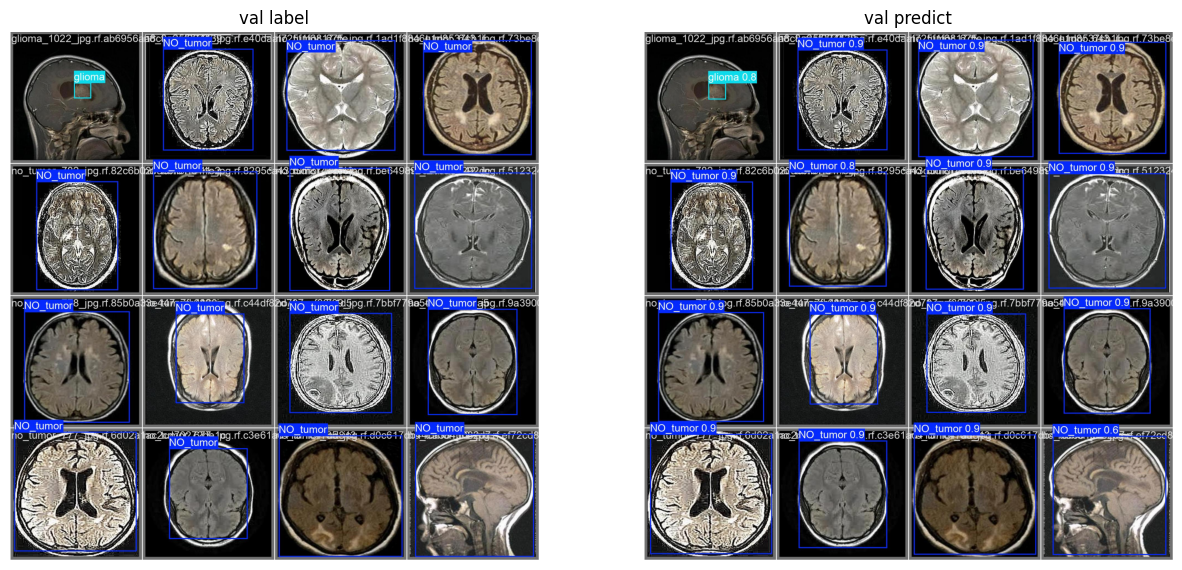

In [ ]:
import cv2
import matplotlib.pyplot as plt

image1 = cv2.imread('train/val_batch0_labels.jpg')
image2 = cv2.imread('train/val_batch0_pred.jpg')

image1 = cv2.cvtColor(image1, cv2.COLOR_BGR2RGB)
image2 = cv2.cvtColor(image2, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15, 10))

plt.subplot(1, 2, 1)
plt.imshow(image1)
plt.title('val label')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(image2)
plt.title('val predict')
plt.axis('off')

plt.show()


image 1/1 /content/img.jpg: 640x640 (no detections), 992.9ms
Speed: 11.4ms preprocess, 992.9ms inference, 10.9ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/drive/MyDrive/Colab/Yolo/Brain Tomor Detection /Tumor data/runs/detect/predict


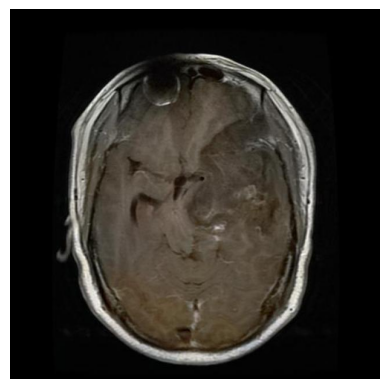

In [10]:
import cv2
import matplotlib.pyplot as plt

#  Load the trained model (best.pt is usually saved inside weights folder)
'''model_path = "/content/drive/MyDrive/Colab/Yolo/Brain Tomor Detection /Tumor data/runs/detect/train3/weights/best.pt"
model = YOLO(model_path)'''

#  Provide the external image path
image_path = "/content/img.jpg"  # change to your own test image

#  Run inference
results = model.predict(source=image_path, save=True, conf=0.25)
# save=True will save the output with boxes inside runs/detect/predict

#  (Optional) Display the image with predictions inline
result_image = results[0].plot()  # returns a numpy array (BGR)
plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()